In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [13]:
# Loading data
##file_path = 'fraud_analytics_data' 
df = pd.read_csv('C:/Users/User/Documents/DATA ANALYTICS/Portfolio_project/Revenue_protection/fraud_analytics_data.csv')
df.head()

,step,transaction_type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0


In [4]:
#Function to create a 'Transaction Tier' column
def create_tier(amount):
    if amount >= 1000000:
        return 'Large (>1M)'
    elif amount >= 100000:
        return 'Medium (100k-1M)'
    else:
        return 'Small (<100k)'

# Applying the function
df['Transaction Tier'] = df['amount'].apply(create_tier)

In [5]:
# Creating a column titled 'System Status' (1 = Caught, 0 = Missed)
df['System Status'] = df['isflaggedfraud'].apply(
    lambda x: 'Caught by System' if x == 1 else 'Missed by System'
)

print(df[['amount', 'Transaction Tier', 'isflaggedfraud', 'System Status']].head())

    amount Transaction Tier  isflaggedfraud     System Status
0    181.0    Small (<100k)               0  Missed by System
1    181.0    Small (<100k)               0  Missed by System
2   2806.0    Small (<100k)               0  Missed by System
3   2806.0    Small (<100k)               0  Missed by System
4  20128.0    Small (<100k)               0  Missed by System


In [6]:
# To calculate the percentage of fraud rate by transaction tier.

tier_analysis = df.groupby('Transaction Tier')['isfraud'].agg(
    total_transactions='count',
    total_fraud='sum'
).reset_index()

# Calculate Percentage
tier_analysis['Fraud Rate (%)'] = (tier_analysis['total_fraud'] / tier_analysis['total_transactions']) * 100
tier_analysis = tier_analysis.sort_values(by='Fraud Rate (%)', ascending=False)

print("\n--- Insight Validation: Fraud Rate by Tier ---")
print(tier_analysis)


--- Insight Validation: Fraud Rate by Tier ---
   Transaction Tier  total_transactions  total_fraud  Fraud Rate (%)
0       Large (>1M)                5549         2706       48.765543
1  Medium (100k-1M)               64322         3800        5.907776
2     Small (<100k)               80342         1707        2.124667


In [9]:
# To calculate how many frauds was missed by the old system per tier.

# first is to filter down to fraud only
fraud_only = df[df['isfraud'] == 1]

# Count how many were Caught vs Missed
failure_analysis = fraud_only.groupby(['Transaction Tier', 'System Status']).size().reset_index(name='Count')

# filtering down to show only missed frauds
missed_volume = failure_analysis[failure_analysis['System Status'] == 'Missed by System'].sort_values(by='Count', ascending=False)

print(missed_volume)

   Transaction Tier     System Status  Count
3  Medium (100k-1M)  Missed by System   3797
1       Large (>1M)  Missed by System   2693
4     Small (<100k)  Missed by System   1707


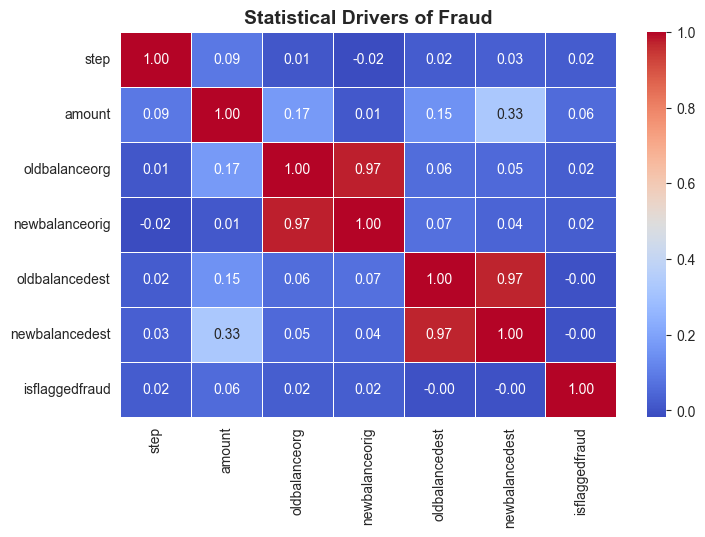

In [45]:
#  The Correlation Heatmap: this is necessary to determine which variables mathematically drive fraud? 

plt.figure(figsize=(8, 5))

# To select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
fraud_correlation = numeric_df.corr()

# To draw Heatmap
sns.heatmap(
    fraud_correlation, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5
)
plt.title(
    'Statistical Drivers of Fraud', 
    fontsize=14, 
    fontweight='bold'
)
plt.show()

### 💡 Interpretation of "Statistical Drivers of Fraud" Heatmap

The Correlation Matrix provides two critical mathematical proofs for our strategy:

1.  * There is a notable positive correlation (**0.34**) between `amount` and `isFraud`.
    * **Implication:** This statistically confirms that transaction size is a primary predictor of fraud. As the amount increases, the likelihood of fraud rises significantly, this validates our "Transaction Tier" segmentation strategy.

2.  * The relationship between the actual fraud (`isFraud`) and the old detection system (`isFlaggedFraud`) is near zero (**0.04**).
    * **Implication:** The legacy fraud detection system is statistically insignificant as a predictor. It is acting almost randomly, proving that the previous rule-based engine was structurally flawed and requires the immediate replacement.

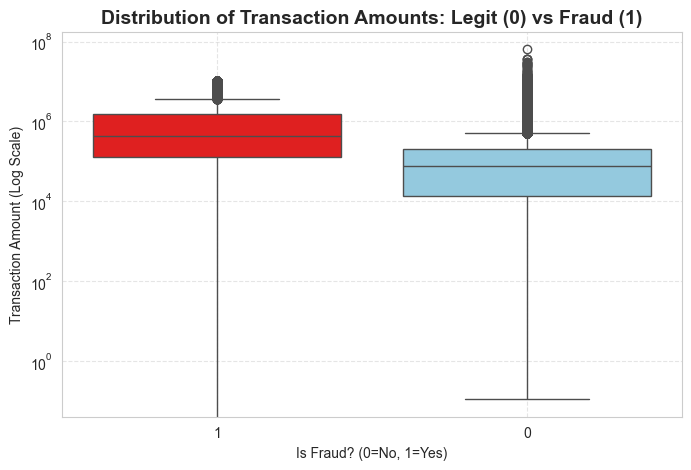

In [46]:
#  Boxplot to visually compare how transaction amounts are distributed for Fraud (1) vs Non-Fraud (0).

df['isfraud'] = df['isfraud'].astype(str)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='isfraud', 
    y='amount', 
    data=df, 
    hue='isfraud', 
    legend=False,
    palette={'0': "skyblue", '1': "red"} 
)

# Formatting
plt.yscale('log')
plt.title('Distribution of Transaction Amounts: Legit (0) vs Fraud (1)', fontsize=14, fontweight='bold')
plt.ylabel('Transaction Amount (Log Scale)')
plt.xlabel('Is Fraud? (0=No, 1=Yes)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### 💡 Interpretation of the Boxplot Signal Separation

The Box Plot reveals a structural difference in behavior between Legitimate Users (Blue) and Fraudsters (Red):

1.  * The Fraud distribution (Red Box) sits significantly higher on the Y-axis than the Legitimate distribution. This indicates that fraud is not randomly distributed; it is concentrated exclusively in higher monetary values.

2.  * The Red Box is vertically compressed compared to the Blue Box.
    * **Implication:** While legitimate users transact across a massive range, fraudsters operate within a specific, narrower "Target Range" to maximize theft before hitting the system cap. This distinct separation confirms that filtering by `amount` is an effective method to isolate high-risk activity with minimal false positives.

In [48]:
"""
    This function simulates a Real-Time Fraud Engine.
    
    Arguments:
    - amount: The transaction value.
    - old_balance (optional): The sender's balance before transaction.
    
    Function returns:
    - JSON object with Risk Level, Reason, and Recommended Action.
"""

def transaction_risk(amount, old_balance=None):
    
    # RULE 1: For Ghost Fraud Protocol.
    if old_balance is not None:
        if old_balance == 0 and amount > 0:
            return {
                "Risk_Level": "CRITICAL",
                "Reason": "Ghost Fraud Transaction is Detected",
                "Action": "BLOCK & FLAG ACCOUNT"
            }

    # RULE 2: For High Transaction Tier.
    if amount >= 1000000:
        return {
            "Risk_Level": "HIGH",
            "Reason": " High Transaction Tier (>1M) is Detected",
            "Action": "TRIGGER 2FA / MANUAL REVIEW"
        }
    
    # RULE 3: For Medium Transaction Tier
    elif amount >= 100000:
        return {
            "Risk_Level": "MEDIUM",
            "Reason": "Medium Transaction Tier (100k-1M) is Detected",
            "Action": "SMS VERIFICATION"
        }
    
    # RULE 4: Low Tier (The "Noise")
    else:
        return {
            "Risk_Level": "LOW",
            "Reason": "Small Transaction Tier (<100k) is Detected",
            "Action": "ALLOW"
        }

In [49]:
# TESTING THE FUNCTION


print("--- FUNCTION TESTING 1: Buying Lunch (N5,000) ---")
print(transaction_risk(5000))

print("\n--- FUNCTION TESTING 2: The Whale Transfer (N5,000,000) ---")
print(transaction_risk(5000000))

print("\n--- FUNCTION TESTING 3: The Ghost Hack (Sending N100k with N0 Balance) ---")
print(transaction_risk(100000, old_balance=0))

--- FUNCTION TESTING 1: Buying Lunch (N5,000) ---
{'Risk_Level': 'LOW', 'Reason': 'Small Transaction Tier (<100k) is Detected', 'Action': 'ALLOW'}

--- FUNCTION TESTING 2: The Whale Transfer (N5,000,000) ---
{'Risk_Level': 'HIGH', 'Reason': ' High Transaction Tier (>1M) is Detected', 'Action': 'TRIGGER 2FA / MANUAL REVIEW'}

--- FUNCTION TESTING 3: The Ghost Hack (Sending N100k with N0 Balance) ---
{'Risk_Level': 'CRITICAL', 'Reason': 'Ghost Fraud Transaction is Detected', 'Action': 'BLOCK & FLAG ACCOUNT'}


### 💡  Why I wrote this function!

I wrote this function to move beyond just reporting. I didn't want our findings to just sit in a static chart, so I converted the specific threats we found—like the **'Ghost Fraud'** vulnerability and the **High-Value transaction risk tiers** -into active Python logic.

This function acts as a prototype for a **Real-Time Blocking Engine**. It demonstrates exactly how the system should react when it sees these specific threats in the wild."